# 9교시 | 텍스트 LLM(Large Language Model) 추론 + 이미지 Captioning (통합)
**환경**: Google Colab | **방법**: 이론 + 실습

---

## 학습 목표

- Chat Template 구조와 시스템 프롬프트의 역할을 설명할 수 있다.
- 프롬프트 변화가 LLM(Large Language Model) 출력에 미치는 영향을 실험으로 확인한다.
- 이미지를 base64로 인코딩하여 VLM(Vision Language Model) API(Application Programming Interface)에 전달하는 구조를 구현한다.
- 프롬프트 유형에 따른 Captioning 품질 차이를 비교한다.

### 처음 읽는 분을 위한 안내

- 이번 교시를 한 줄로 보면: 텍스트 LLM(Large Language Model) 대화 구조와 이미지 Captioning이 하나의 입력-출력 흐름으로 이어진다는 점을 이해하는 시간이다.
- 처음에는 여기까지 이해하면 충분하다: 시스템 프롬프트가 답변 스타일을 바꾸고, 이미지가 들어오면 같은 모델이 장면 설명도 할 수 있다는 정도만 잡아도 된다.
- 헷갈려도 괜찮은 부분: Chat Template, base64, projection 같은 용어가 한 번에 많아 보여도 괜찮다. 먼저 "텍스트만 넣을 때"와 "이미지까지 넣을 때"의 차이를 구분하는 것이 중요하다.


- Note  
  ChatTemplate : ChatML 형식으로 메시지를 구성하는 틀
                 예) {"role": "system", "content": "prompt"}, {"role": "user", "content": "질문"}, {"role": "assistant", "content": "답변"}
  필요한 이유 : 아래 특수 토큰은 모델마다 다르기때문에 ChatTemplate을 통해 사용하면 모델별에 맞춰 자동으로 바꾸어 준다네
**Qwen3의 경우 특수 토큰**
- `<|im-start|>` / `<|im_end|>`: 시작과 끝을 표시하는 토큰
- `<|vision_start|>` / `<|vision_end|>`: 이미지 시퀀스 경계 표시
- `<|image_pad|>`: 이미지 패치 자리를 표시하는 플레이스홀더로 visin_start와 vision_end 사이에 들어간다.
- `<think>` / `</think>`: Thinking 모드의 추론 구간 구분

 
### 용어 미니사전

| 용어 | 아주 쉽게 말하면 |
|---|---|
| System Prompt | 모델이 어떤 역할과 말투로 답할지 정하는 상위 지시 |
| Chat Template | 대화를 모델 입력 형식으로 정리한 틀 |
| Temperature | 답변을 얼마나 보수적 또는 다양하게 만들지 조절하는 값 |
| Captioning | 이미지를 보고 설명 문장을 만드는 작업 |
| Base64 | 이미지를 문자열처럼 전달하기 위한 인코딩 방식 |
| VLM(Vision Language Model) | 텍스트와 이미지를 함께 처리하는 모델 |

---

## 이론 (텍스트 LLM 추론)

### 먼저 큰 그림부터 이해하기

이번 차시는 사실 두 가지를 한 번에 묶어 보여 준다.  
앞부분은 **텍스트 LLM이 어떻게 대화를 처리하는가**, 뒷부분은 **그 구조에 이미지를 추가하면 어떻게 VLM이 되는가**를 다룬다.

즉, 이 문서는 두 개의 서로 다른 주제가 아니라 다음 흐름으로 이해하는 것이 중요하다.

1. 텍스트만 있을 때는 `시스템 프롬프트 + 사용자 메시지`가 토큰으로 바뀌어 LLM으로 들어간다.
2. 이미지까지 있을 때는 이미지도 별도의 인코더를 거쳐 토큰 또는 임베딩 형태로 바뀐다.
3. 결국 LLM은 텍스트 토큰만 보는 것이 아니라, **텍스트와 연결된 시각 정보까지 함께 받아** 응답을 생성한다.

이 큰 그림을 잡고 보면, Captioning은 새로운 마법이 아니라 **"텍스트 추론 파이프라인에 이미지 정보가 추가된 경우"** 로 이해할 수 있다.

### 실제 LLM 추론 파이프라인

```
사용자 입력
  ↓
시스템 프롬프트 + 사용자 메시지 → Chat Template 적용
  ↓
Tokenization
  ↓
모델 추론 (KV Cache 활성화)
  ↓
스트리밍 또는 일괄 응답
  ↓
Detokenization → 사용자 출력
```

이 과정을 직관적으로 보면, 사용자가 보는 자연어 대화는 내부적으로는 모두 **역할이 붙은 텍스트 시퀀스**로 바뀐다. 모델은 이 시퀀스를 받아 다음 토큰을 한 개씩 예측하며 응답을 생성한다. 즉, `대화를 한다`는 것은 내부적으로 `특정 형식의 토큰 시퀀스를 이어서 생성한다`는 뜻이다.

### Chat Template 구조

GPT/OpenAI ChatML 형식:

```
전달  
<|system|>
You are a helpful assistant.
<|user|>
LLM이 무엇인지 한 문장으로 설명해줘.
<|assistant|>
응답  
LLM은 대규모 텍스트 데이터로 사전 학습된...
```

- **system**: 모델의 페르소나, 응답 형식, 제약 사항 설정
- **user**: 사용자 입력
- **assistant**: 모델 응답 (멀티턴 대화에서 이전 응답 포함)

여기서 `system`의 역할을 특히 분명히 이해해야 한다. `system`은 단순한 안내 문장이 아니라, 모델이 이후 대화를 어떤 규칙으로 해석할지 정하는 상위 맥락이다. 그래서 같은 `user` 질문이라도 `system`이 달라지면 답변의 길이, 말투, 형식, 우선순위가 달라질 수 있다.

### 프롬프트 엔지니어링의 원리

| 기법 | 원리 | 효과 |
|---|---|---|
| 시스템 프롬프트 | 모델이 응답 전략을 선택하는 맥락 제공 | 페르소나, 형식 제어 |
| Chain-of-Thought | "단계적으로 생각해봐" 지시 | 추론 성능↑ |
| Few-shot | 입력-출력 예시 제공 | 출력 형식 유도 |
| Role Assignment | 전문가 역할 부여 | 더 전문적인 답변 |

핵심은 프롬프트가 모델의 지식을 새로 넣는 것이 아니라, **이미 가진 지식을 어떤 방식으로 꺼내 쓰게 할지 조정한다**는 점이다. 즉, 좋은 프롬프트는 모델을 더 똑똑하게 만든다기보다, 더 적절한 경로로 답하게 만든다.

### Chain-of-Thought가 효과적인 이유

LLM은 Autoregressive 생성이므로 "중간 단계 토큰"을 생성하게 하면 내부 표현이 풍부해진다. 단계적 사고를 명시하면 모델이 최종 답변 전에 추론 과정을 "종이에 쓰듯" 생성할 수 있다.

물론 모든 문제에서 길게 생각 과정을 쓰는 것이 항상 최선은 아니다. 간단한 질의에서는 불필요하게 토큰을 많이 쓰게 만들 수 있고, 잘못된 중간 추론이 길어질 수도 있다. 그래서 실무에서는 `정확성이 중요한 문제에서는 더 구조적 추론`, `짧고 빠른 응답이 중요한 경우에는 간결한 지시`처럼 목적에 따라 조절하는 편이 좋다.

---

## 이론 (Image Captioning)

### 텍스트 LLM에서 VLM으로 확장되는 방식

텍스트 LLM은 원래 텍스트 토큰만 입력으로 받는다. 그렇다면 이미지는 어떻게 들어갈까?  
핵심은 이미지를 직접 문자처럼 넣는 것이 아니라, 먼저 비전 인코더가 처리해 **LLM이 받아들일 수 있는 표현 공간**으로 변환한 뒤 텍스트와 함께 넣는 것이다.

즉, VLM은 대략 아래와 같이 생각하면 된다.

```
텍스트 입력 → 토큰화 → LLM 입력
이미지 입력 → Vision Encoder → Projection → LLM 입력
둘을 함께 조건으로 사용 → 다음 토큰 생성
```

- Note   
 이미지토큰               -> 텍스트토큰             ->캡션  
  (이미지-패치 d_model)       (d_model)  
       텍스트토큰 d_model*n  
  Projection(== MLP) : 이미지 토큰을 텍스트 토큰과 같은 차원으로 맞춰주는 역할  
  (이미지-패치 d_model)       (d_model)  
  (이미지-패치 d_model*n)     (d_model*n)  

이렇게 보면 Captioning은 `이미지를 보고 그 내용을 언어로 번역하는 과정`이라고 이해할 수 있다.

### VLM의 이미지 입력 구조

```
이미지 파일
  ↓ Base64 인코딩 (서버에 업로드하고 URL을 주면 Base64로 변환 생략가능)  
Base64 문자열
  ↓ data URL 형식 ("data:image/jpeg;base64,...")
OpenAI API content 블록
  ↓ 서버에서 디코딩 → ViT 처리 → 이미지 임베딩
LLM Decoder에 이미지 토큰 + 텍스트 토큰 함께 입력
  ↓
캡션 생성
```

API 실습에서는 이미지를 base64 문자열로 바꿔 보내지만, 이것은 어디까지나 **전송 형식**이다. 중요한 것은 서버 내부에서 다시 디코딩된 이미지가 vision encoder를 통과해 임베딩으로 바뀌고, 그 임베딩이 텍스트와 함께 모델 조건으로 들어간다는 점이다. 즉, base64는 모델 이해 방식이 아니라 API 전달 방식이다.

### Visual Projection의 역할

이미지 임베딩(예: ViT 출력 차원 768~1024)과 LLM 입력 차원(예: 4096)이 다르므로 **MLP Connector**로 연결한다.

```
ViT 출력: (196, 768)   ← 패치 토큰 196개, 각 768차원
  ↓ MLP Projection
LLM 입력: (196, 4096)  ← LLM 차원으로 변환
```

이 projection은 단순 차원 맞춤 이상의 의미를 갖는다. 비전 인코더가 만든 표현을 LLM이 익숙한 표현 공간 쪽으로 옮겨 주는 일종의 "번역기" 역할을 하기 때문이다. 그래서 많은 VLM에서 connector나 adapter 설계가 전체 성능에 큰 영향을 준다.

### 캡션 품질에 영향을 주는 요소

- 이미지 해상도 (고해상도 → 세부 묘사 가능)
- Visual Encoder 크기 (ViT-B vs ViT-L vs ViT-G)
- 여기서 `B`, `L`, `G`는 각각 `Base`, `Large`, `Giant`를 뜻한다. 즉, 같은 Vision Transformer 계열이라도 모델 크기가 달라질 수 있으며, 보통 더 큰 모델일수록 표현력은 좋아질 수 있지만 계산량과 메모리 사용량도 함께 커진다.
- 프롬프트 구체성 ("설명해줘" vs "색상, 질감, 배경을 포함해 상세히 설명해줘")
- 언어 설정 (한국어 요청 가능)

여기에 하나를 더 붙이면, 캡션 품질은 **무엇을 묻느냐** 에도 크게 좌우된다. `무엇이 보이나요?`는 요약을 유도하고, `배경, 질감, 조명, 분위기를 포함해 설명해 주세요`는 세부 묘사를 유도한다. 즉, 모델의 시각 능력만큼이나 질문 설계가 결과를 바꾼다.

### 이론을 읽을 때 꼭 잡아야 할 연결 고리

이 단원에서는 아래 흐름이 연결되어야 한다.

1. Chat Template는 대화를 역할이 있는 입력 구조로 바꾼다.
2. 시스템 프롬프트는 응답 전략과 형식을 크게 바꾼다.
3. Temperature는 다음 토큰 선택 분포를 바꿔 창의성과 안정성에 영향을 준다.
4. 이미지는 비전 인코더와 projection을 거쳐 텍스트와 함께 LLM 입력 조건이 된다.
5. 그래서 Captioning 결과는 이미지 자체뿐 아니라 프롬프트 설계에도 크게 영향을 받는다.

---

## 실습

### Part A — 텍스트 LLM 추론 실험

실습은 아래 순서대로 **한 단계씩 실행**하는 것을 권장한다.  
이번 차시는 크게 두 부분으로 나뉜다.

1. Part A: 텍스트 LLM에서 시스템 프롬프트와 Temperature의 효과 관찰하기
2. Part B: 이미지를 base64로 인코딩해 VLM Captioning 결과를 비교하기

각 코드 블록은 바로 위 설명과 연결되므로, 한 셀을 실행한 뒤 출력 결과를 확인하고 다음 셀로 넘어가면 된다.

### 자주 막히는 오류

- OpenAI API 인증 오류: 1교시에서 등록한 API Key가 현재 세션 환경변수에 다시 로드되었는지 확인한다.
- JSON 형식 응답이 완벽하지 않음: 프롬프트가 형식을 강하게 유도해도 모델 출력은 약간 흔들릴 수 있다.
- 이미지 Captioning 호출 오류: base64 문자열 자체보다 메시지 형식(`image_url` + `text`)이 맞는지 먼저 본다.
- 한국어/영어 결과 차이: 같은 이미지라도 요청 언어와 프롬프트 구체성에 따라 답변 길이와 초점이 달라질 수 있다.

### 실패했을 때 체크 순서

1. 텍스트 실험인지 이미지 Captioning 실험인지 먼저 구분한다: 입력 형식이 서로 다르다.
2. API Key와 메시지 구조를 먼저 본다: 인증, `messages`, `image_url` 형식이 맞아야 다음 단계가 의미 있다.
3. 가장 단순한 프롬프트로 다시 실행한다: 짧은 텍스트 요청이나 기본 캡션 요청부터 복구한 뒤 비교 실험으로 돌아간다.

#### Step A0. 텍스트 LLM 실험 준비

먼저 OpenAI 클라이언트를 준비하고, 반복 실험에 사용할 `chat()` 함수를 만든다.

In [2]:
from openai import OpenAI
import time
from google.colab import userdata

api_key = userdata.get("OPENAI_API_KEY")
if not api_key:
  raise ValueError("Colab Secrets에 OPENAI_API_KEY를 먼저 등록하세요.")

client = OpenAI(api_key=api_key)

def chat(system, user, temperature=1.0, max_tokens=300, model="gpt-4.1-mini"):
  start = time.time()
  resp = client.chat.completions.create(
    model=model,
    messages=[
      {"role": "system", "content": system},
      {"role": "user", "content": user},
    ],
    temperature=temperature,
    max_tokens=max_tokens,
  )
  elapsed = time.time() - start
  return resp.choices[0].message.content, resp.usage, elapsed

이 단계에서 확인할 점:

- 이 단계는 단순히 API를 한 번 호출하는 코드가 아니라, 이후 실험에서 반복해서 사용할 공통 함수 `chat()`를 만드는 단계다. 즉, 다음 Step A1, A2, A3에서는 매번 긴 API 호출 코드를 다시 쓰지 않고, 이 함수에 조건만 바꿔 넣어 실험하게 된다.
- `system`은 모델의 역할, 말투, 답변 전략을 정하는 입력이다. 예를 들어 "친절한 도우미", "수학 전문가", "단계적으로 생각하는 조교"처럼 같은 질문이라도 다른 방식으로 답하게 만들 수 있다.
- `user`는 실제 질문 내용이다. 즉, 우리가 모델에게 무엇을 물을지를 담는 부분이다. 이후 실험에서는 같은 `user` 질문을 유지한 채 `system`만 바꿔 보기도 하고, 반대로 질문 내용을 바꿔 보기도 한다.
- `temperature`는 답변이 얼마나 보수적일지, 얼마나 다양하게 나올지를 조절하는 값이다. 그래서 이 함수를 만들어 두면 나중에 `temperature=0.1`, `0.7`, `1.5`처럼 숫자만 바꿔 창의성 차이를 손쉽게 비교할 수 있다.
- 반환값이 세 개인 것도 중요하다. 첫 번째는 실제 모델 답변 내용이고, 두 번째는 토큰 사용량(`resp.usage`), 세 번째는 실행 시간(`elapsed`)이다. 즉, 이 함수는 단순히 "무슨 답을 했는가"만이 아니라, "얼마나 많은 토큰을 썼는가", "얼마나 오래 걸렸는가"까지 함께 관찰할 수 있게 해 준다.
- 이것이 필요한 이유는, 프롬프트를 바꾸면 답변 내용만 달라지는 것이 아니라 토큰 사용량과 응답 시간도 함께 달라질 수 있기 때문이다. 예를 들어 단계적 사고를 유도하면 답이 더 길어지고, 그만큼 토큰도 더 많이 쓰는 경향이 있다.
- 따라서 이 단계의 핵심은 "앞으로의 모든 텍스트 LLM 실험을 같은 틀로 비교할 수 있도록, 입력 조건(system, user, temperature)과 관찰 결과(응답, 토큰, 시간)를 한 번에 다루는 실험용 함수가 준비되었다"는 점을 이해하는 것이다.

#### Step A1. Chain-of-Thought 효과 실험

같은 질문에 대해 시스템 프롬프트만 바꿔 응답이 어떻게 달라지는지 본다.

In [5]:
print("=" * 60)
print("[실험 1] Chain-of-Thought 효과")
print("질문: '9.8과 9.11 중 어느 것이 더 큰가?'")
print("=" * 60)

question = "9.8과 9.11 중 어느 것이 더 큰가? 정답과 이유를 알려줘."

systems = {
  "기본": "You are a helpful assistant.",
  "단계적 사고": "You are a helpful assistant. Think step by step before answering.",
  "수학 전문가": "You are a precise math tutor. Show your reasoning clearly.",
}

for name, sys_prompt in systems.items():
  answer, usage, elapsed = chat(sys_prompt, question)
  print(f"\n[{name}] ({usage.total_tokens} tokens, {elapsed:.2f}s)")
  print(answer)

[실험 1] Chain-of-Thought 효과
질문: '9.8과 9.11 중 어느 것이 더 큰가?'

[기본] (186 tokens, 1.81s)
9.8과 9.11 중에서 더 큰 수는 9.8입니다.

이유:  
- 9.8은 소수점 아래 한 자리 숫자입니다.  
- 9.11은 소수점 아래 두 자리 숫자이며, 9.11은 9.1보다 크고 9.8보다 작습니다.  

좀 더 자세히 비교하면,  
- 9.8은 9.80으로 생각할 수 있습니다.  
- 9.11은 9.11이므로, 9.80 > 9.11입니다.  

따라서 9.8이 9.11보다 더 큽니다.

[단계적 사고] (152 tokens, 1.16s)
9.8과 9.11 중에서는 9.8이 더 큽니다.

이유: 소수점 아래 첫째 자리 숫자를 비교하면,
- 9.8은 9.8 (9와 8/10)
- 9.11은 9.11 (9와 11/100)

9.8은 9.80과 같으므로 9.80 > 9.11 입니다. 따라서 9.8이 더 큽니다.

[수학 전문가] (219 tokens, 2.35s)
9.8과 9.11 중 어느 것이 더 큰지 비교해 보겠습니다.

- 9.8은 소수점 이하가 8입니다.
- 9.11은 소수점 이하가 11입니다.

소수점 아래 첫 번째 자리부터 비교할 때:

- 9.8은 9.8 = 9.80으로 생각할 수 있습니다.
- 9.11은 9.11입니다.

이제 9.80과 9.11을 비교하면, 9.80이 더 큽니다.

따라서, **9.8이 9.11보다 더 큽니다**.

**이유:** 9.8은 9.80으로 표현할 수 있는데, 9.80은 9.11보다 크기 때문입니다.


이 단계에서 확인할 점:

- 이 실험에서 가장 먼저 봐야 할 것은 세 경우 모두 최종 정답이 같다는 점이다. `기본`, `단계적 사고`, `수학 전문가` 모두 `9.8이 더 크다`는 같은 결론에 도달했다. 즉, 시스템 프롬프트는 모델의 지식을 새로 바꾸는 것이 아니라, 같은 문제를 어떤 방식으로 설명하게 만들지를 조정한다고 이해하면 된다.
- 달라지는 부분은 "정답 자체"보다 "설명 방식"이다. `기본`은 일반적인 설명으로 답하고, `단계적 사고`는 비교 과정을 조금 더 순서 있게 보여 주며, `수학 전문가`는 교사가 풀이를 설명하듯 더 정돈된 표현으로 답한다. 즉, 시스템 프롬프트에 따라 답변의 말투, 구조, 강조 방식이 바뀌는지를 보는 단계다.
- 이번 결과에서는 `단계적 사고`가 반드시 가장 긴 답을 만들지는 않았다. 오히려 `기본`은 `186 tokens`, `단계적 사고`는 `152 tokens`, `수학 전문가`는 `219 tokens`로 나왔다. 이것은 "Chain-of-Thought 지시 = 무조건 가장 긴 답변"이라는 뜻이 아니라, 프롬프트에 따라 설명 구조와 토큰 사용량이 달라질 수 있다는 뜻이다.
- 특히 `수학 전문가`가 가장 많은 토큰을 사용한 점도 중요하다. 이는 전문가 역할을 부여하면 모델이 더 정돈된 풀이, 강조 문장, 설명 표현을 추가하려는 경향이 생길 수 있음을 보여 준다. 즉, 역할 지시는 답변 스타일뿐 아니라 길이와 비용에도 영향을 줄 수 있다.
- 실행 시간도 함께 볼 필요가 있다. 여기서는 대략 `1.16s ~ 2.35s` 사이로 차이가 났는데, 보통 답변이 길어지거나 생성 토큰 수가 많아질수록 시간이 늘어날 가능성이 있다. 그래서 프롬프트를 바꾼다는 것은 단지 표현을 바꾸는 것뿐 아니라, 토큰 비용과 지연시간에도 영향을 주는 실험이라고 이해하는 것이 좋다.
- 따라서 이 단계의 핵심은 "같은 질문이라도 시스템 프롬프트에 따라 답변의 형식, 설명 방식, 토큰 사용량, 응답 시간이 달라질 수 있다"는 점을 실제 출력으로 확인하는 것이다. 즉, 프롬프트 엔지니어링은 정답을 바꾸는 마법이라기보다, 같은 지식을 어떤 방식과 비용으로 꺼내게 할지를 조정하는 도구라고 보면 된다.

#### Step A2. 시스템 프롬프트로 출력 형식 제어하기

이번에는 같은 주제라도 시스템 프롬프트에 따라 응답 형식이 어떻게 바뀌는지 본다.

In [6]:
print("\n" + "=" * 60)
print("[실험 2] 출력 형식 제어")
print("=" * 60)

topic = "LLM의 장단점을 설명해줘."

format_systems = {
  "자유 형식": "You are a helpful assistant.",
  "JSON 형식": 'You are a helpful assistant. Always respond in JSON format with keys: "advantages" and "disadvantages" as lists.',
  "표 형식": "You are a helpful assistant. Respond using a markdown table with columns: 구분, 내용, 예시.",
  "한국어 초등학생용": "You are explaining complex topics to elementary school students in Korean. Use simple words and short sentences.",
}

for name, sys_prompt in format_systems.items():
  answer, _, _ = chat(sys_prompt, topic, max_tokens=200)
  print(f"\n[{name}]")
  print(answer)


[실험 2] 출력 형식 제어

[자유 형식]
물론입니다! LLM(대형 언어 모델, Large Language Model)의 장단점에 대해 간단히 설명해드릴게요.

### 장점
1. **자연스러운 언어 생성**  
   매우 자연스럽고 유창한 문장을 생성할 수 있어, 인간과의 의사소통이 쉽습니다.

2. **다양한 작업 수행 가능**  
   번역, 요약, 질문 답변, 글쓰기 보조 등 다양한 언어 관련 작업에 활용할 수 있습니다.

3. **대량의 지식 내장**  
   방대한 텍스트 데이터를 학습해 여러 분야에 걸친 지식을 갖추고 있습니다.

4. **사용자 맞춤형 응답 가능**  
   특정 문맥이나 요구에 맞춰 적절한 답변을 제공할 수 있습니다.

5. **24시간 가용성**  
   휴식 없이 언제든지 서비스를 제공할 수

[JSON 형식]
```json
{
  "advantages": [
    "다양한 언어와 주제에 대한 광범위한 이해와 응답 가능",
    "자연스러운 언어 생성으로 인간과 유사한 대화 경험 제공",
    "빠른 정보 검색 및 요약 능력",
    "자동화된 문서 작성, 번역, 리뷰 등의 작업 지원",
    "학습 및 개발에 필요한 자료 생성에 유용",
    "24시간 가동 가능하여 언제든지 서비스 제공 가능"
  ],
  "disadvantages": [
    "가끔 부정확하거나 편향된 정보를 생성할 수 있음",
    "복잡한 논리적 추론이나 창의적 문제 해결에 한계 있음",
    "대량의 계산 자원과 데이터 학습이 필요하여 비용이 높음",
    "프라이버시 및 보안 문제 발생 가능성",
    "훈련 데이터에 기반한 편향과

[표 형식]
| 구분 | 내용 | 예시 |
|---|---|---|
| 장점 | 대량의 텍스트 데이터를 학습하여 자연스러운 언어 생성이 가능하다. | 고객 상담 챗봇, 자동 번역 서비스 |
| 장점 | 다양한 분야의 질문에 대해 폭넓은 지식 기반에서 답변할 수 있다. | 의료 상담, 법률 자문 

이 단계에서 확인할 점:

- 이 실험에서 가장 먼저 봐야 할 것은, 질문 주제는 모두 `LLM의 장단점`으로 같지만 출력 모양은 크게 달라졌다는 점이다. 즉, 모델이 갑자기 다른 지식을 배운 것이 아니라, 같은 내용을 어떤 형식으로 정리해 보여 줄지를 시스템 프롬프트가 바꿔 준다고 이해하면 된다.
- `자유 형식`은 일반적인 설명문처럼 자연스럽게 장점과 단점을 풀어 쓴다. 이런 형식은 사람이 읽기 편하지만, 항목 구조가 엄격하지 않아서 프로그램이 바로 처리하기는 상대적으로 어렵다.
- `JSON 형식`은 `advantages`, `disadvantages` 같은 고정된 key를 가진 구조화된 출력으로 바뀐다. 이것은 사람이 읽기 위한 답변이라기보다, 다른 프로그램이나 후속 코드가 결과를 쉽게 파싱하고 활용할 수 있는 형식이라는 점이 중요하다.
- `표 형식`은 같은 내용을 `구분 | 내용 | 예시`처럼 열과 행으로 정리한다. 즉, 정보를 비교해서 보기 쉽게 만들고 싶을 때는 표 형식이 유리하다는 점을 보여 준다.
- `한국어 초등학생용`은 내용 자체보다 설명 수준이 달라진 예시다. 같은 주제라도 쉬운 단어, 짧은 문장, 친숙한 표현으로 바뀌었으므로, 시스템 프롬프트는 형식뿐 아니라 난이도와 대상 독자 수준까지 조절할 수 있다는 점을 알 수 있다.
- 여기서 중요한 핵심은, 시스템 프롬프트가 모델의 "답변 스타일 설정" 역할을 한다는 점이다. 즉, 같은 질문이라도 JSON이 필요하면 JSON으로, 표가 필요하면 표로, 어린이 설명이 필요하면 쉬운 한국어로 바꿀 수 있다.
- 다만 출력 형식을 강하게 요구해도 항상 완벽하게 지켜지는 것은 아니라는 점도 함께 기억해야 한다. 실제 사용에서는 JSON 누락, 표 형식 흔들림, 설명 길이 차이처럼 약간의 변동이 생길 수 있으므로, 중요한 시스템에서는 후처리나 검증이 필요할 수 있다.
- 따라서 이 단계의 핵심은 "시스템 프롬프트는 단순한 말투 변경이 아니라, 같은 내용을 어떤 형식과 수준으로 표현할지를 제어하는 강력한 도구"라는 점을 실제 출력으로 확인하는 것이다.

#### Step A3. Temperature 창의성 실험

같은 요청에 대해 Temperature만 바꿔 창의성 차이를 비교한다.

In [7]:
print("\n" + "=" * 60)
print("[실험 3] Temperature 창의성 실험")
print("=" * 60)

poem_prompt = "AI에 관한 짧은 시를 2~3줄로 써줘."
sys_creative = "You are a creative poet."

for temp in [0.1, 0.7, 1.5]:
  poem, _, _ = chat(sys_creative, poem_prompt, temperature=temp, max_tokens=100)
  print(f"\n[Temperature={temp}]")
  print(poem)


[실험 3] Temperature 창의성 실험

[Temperature=0.1]
전선 속 빛나는 생각의 씨앗,  
무한한 꿈을 짓는 AI의 노래.

[Temperature=0.7]
보이지 않는 선 위를 걷는 AI,  
생각의 바다에 빛나는 별 하나.

[Temperature=1.5]
빛과 코드 사이 인공지능,
지혜 품어 세상과 소통하네.


이 단계에서 확인할 점:

- 이 실험에서 먼저 이해해야 할 점은, 질문은 모두 `AI에 관한 짧은 시를 2~3줄로 써줘`로 같고 시스템 프롬프트도 같지만, `Temperature` 값만 바꾸었다는 점이다. 즉, 이 단계는 모델의 지식이 바뀌는 실험이 아니라, 같은 요청을 얼마나 안정적으로 또는 얼마나 다양하게 표현하는지 보는 실험이다.
- `Temperature=0.1` 결과를 보면 표현이 비교적 차분하고 보수적이다. 문장이 크게 튀지 않고, 모델이 "가장 무난하고 가능성이 높은 표현"을 고르는 쪽으로 움직였다고 이해하면 된다. 그래서 비슷한 요청을 여러 번 실행하면 비교적 비슷한 스타일이 나올 가능성이 높다.
- `Temperature=0.7`은 보통 많이 사용하는 중간 영역으로, 안정성과 다양성의 균형을 보여 준다. 이번 결과에서도 너무 단조롭지도 않고, 그렇다고 지나치게 예측 불가능하지도 않다. 교육생은 이 값을 "적당히 자연스럽고 적당히 창의적인 기본값"처럼 받아들이면 된다.
- `Temperature=1.5`는 표현의 자유도가 더 커진 상태다. 이번 출력에서도 문장 연결과 표현 선택이 좀 더 과감하고 즉흥적으로 느껴진다. 이런 높은 값은 독특한 표현을 얻고 싶을 때 유용하지만, 반대로 문장 품질이 들쑥날쑥해지거나 엉뚱한 방향으로 튈 가능성도 함께 커진다.
- 여기서 중요한 것은 `Temperature가 높다 = 무조건 더 좋다`가 아니라는 점이다. 낮은 값은 일관성과 재현성이 중요할 때 유리하고, 높은 값은 창의적 아이디어나 다양한 표현이 필요할 때 유리하다. 즉, 목적에 따라 적절한 값을 선택해야 한다.
- 예를 들어 요약, 분류, 정보 추출처럼 정확하고 일정한 답변이 중요한 작업은 낮은 Temperature가 더 적합하다. 반대로 시 쓰기, 카피 문구 만들기, 아이디어 브레인스토밍처럼 다양한 표현이 필요한 작업은 중간 또는 높은 Temperature가 더 잘 맞을 수 있다.
- 따라서 이 단계의 핵심은, `Temperature`가 모델의 정답 지식을 바꾸는 버튼이 아니라 "답변의 다양성, 안정성, 창의성의 정도"를 조절하는 손잡이라는 점을 실제 출력으로 확인하는 것이다.

---

### Part B — 이미지 Captioning

#### Step B0. 이미지 Captioning 준비

이미지를 base64 문자열로 바꾸는 함수와, 이미지+텍스트를 함께 보내는 캡션 함수를 만든다.

In [16]:
import base64
import requests
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

def image_url_to_b64(url: str, max_size: int = 512) -> str:
  response = requests.get(
    url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=20,
  )
  response.raise_for_status()

  content_type = response.headers.get("Content-Type", "")
  if not content_type.startswith("image/"):
    raise ValueError(f"이미지 URL이 아닙니다: {url} (Content-Type: {content_type})")

  img = Image.open(BytesIO(response.content)).convert("RGB")

  # 너무 큰 이미지는 축소해 API 비용을 줄인다.
  if max(img.size) > max_size:
    ratio = max_size / max(img.size)
    new_size = (int(img.size[0] * ratio), int(img.size[1] * ratio))
    img = img.resize(new_size, Image.LANCZOS)

  buf = BytesIO()
  img.save(buf, format="JPEG", quality=85)
  return base64.b64encode(buf.getvalue()).decode(), img

def caption_image(b64: str, prompt: str, max_tokens: int = 300) -> str:
  resp = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[{
      "role": "user",
      "content": [
        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
        {"type": "text", "text": prompt},
      ],
    }],
    max_tokens=max_tokens,
  )
  return resp.choices[0].message.content

이 단계에서 확인할 점:

- 이 단계는 아직 "캡션 결과가 잘 나왔는지"를 보는 단계가 아니라, 뒤에서 반복해서 쓸 입력 준비 도구를 만드는 단계다. 즉, Step B1, Step B2, Step B3가 잘 실행되려면 여기의 두 함수가 먼저 정확히 이해되어야 한다.
- `image_url_to_b64()` 함수의 역할은 한 문장으로 말하면 `인터넷 이미지 주소를 받아서, 모델이 전송받을 수 있는 문자열 형태로 바꾸는 것`이다. 초심자는 이 과정을 "이미지를 직접 들고 가는 대신, 이미지 내용을 문자로 포장해서 보내는 준비"라고 생각하면 된다.
- 이 함수 안에서 먼저 `requests.get()`으로 이미지를 내려받고, `raise_for_status()`로 주소가 실제로 열리는지 확인한다. 즉, 링크가 깨졌거나 서버가 오류를 주면 여기서 바로 알 수 있다. 교육생은 이것을 "이미지 분석 전에 먼저 파일을 정상적으로 가져왔는지 검사하는 단계"로 이해하면 된다.
- 이어서 `Content-Type`가 `image/...`로 시작하는지도 확인한다. 이것이 중요한 이유는, 어떤 URL은 겉으로 보기에는 이미지 링크처럼 보여도 실제로는 HTML 오류 페이지나 차단 페이지를 돌려줄 수 있기 때문이다. `UnidentifiedImageError` 같은 문제를 줄이려면, 먼저 "정말 이미지 응답이 맞는지" 확인하는 습관이 필요하다.
- 그다음 `Image.open(...).convert("RGB")`는 내려받은 데이터를 실제 이미지 객체로 여는 부분이다. 여기까지 성공하면 비로소 "이 URL은 PIL(Python Imaging Library)로 읽을 수 있는 정상 이미지다"라고 볼 수 있다.
- 이미지 크기를 줄이는 부분도 그냥 부가 기능이 아니다. 너무 큰 이미지는 전송량이 커지고 처리 시간이 늘어나며 API 비용도 커질 수 있다. 그래서 `max_size=512`는 품질을 완전히 버리지 않으면서도 실습을 가볍고 안정적으로 만들기 위한 현실적인 제한이라고 이해하면 된다.
- 이 함수가 반환하는 값이 두 개인 것도 중요하다. 첫 번째 `base64 문자열`은 API에 실제로 보낼 데이터이고, 두 번째 `img`는 `matplotlib`로 화면에 보여 주기 위한 이미지 객체다. 즉, 하나는 `전송용`, 하나는 `확인용`이라고 보면 이해가 쉽다.
- `caption_image()` 함수는 준비된 이미지 문자열과 질문(prompt)을 하나의 요청으로 묶어 모델에 보내는 역할을 한다. 여기서 핵심은, 이미지 Captioning이 "이미지만 보내는 작업"도 아니고 "텍스트만 보내는 작업"도 아니라는 점이다. 항상 `이미지 + 질문`이 함께 들어가야 모델이 무엇을 어떤 관점으로 설명할지 결정할 수 있다.
- `messages` 안에 `image_url`과 `text`가 같이 들어 있는 구조를 꼭 눈여겨봐야 한다. 이것이 바로 멀티모달 입력(Multimodal Input)의 가장 단순한 예다. 텍스트 LLM 실습에서는 글만 넣었지만, 여기서는 이미지와 글을 한 요청 안에 함께 넣는다는 점이 가장 큰 차이다.
- 특히 `data:image/jpeg;base64,...` 부분은 문자열로 바뀐 이미지 데이터를 다시 `모델이 이해할 수 있는 이미지 전달 형식`으로 감싸는 부분이다. 초심자는 이 줄을 자세히 외우기보다, "이미지를 문자로 바꾼 뒤 다시 API 규칙에 맞는 이미지 주소 모양으로 넣는다"는 흐름만 잡아도 충분하다.
- 따라서 이 단계의 핵심은, 이미지 Captioning 전체 과정이 `이미지 URL 확인 -> 정상 이미지 다운로드 -> base64 변환 -> data URL 포장 -> 질문과 함께 API 전송 -> 설명 생성` 순서로 이루어진다는 점을 이해하는 것이다. 이 흐름을 이해하면 이후 오류가 나더라도 어느 단계에서 문제가 생겼는지 훨씬 쉽게 추적할 수 있다.

#### Step B1. 테스트 이미지와 프롬프트 준비

두 장의 테스트 이미지와 여러 종류의 캡션 프롬프트를 준비한다.

In [14]:
test_images = {
  "ant": "https://upload.wikimedia.org/wikipedia/commons/a/a7/Camponotus_flavomarginatus_ant.jpg",
  "cuisine": "https://images.unsplash.com/photo-1504674900247-0877df9cc836?auto=format&fit=crop&w=1200&q=80",
}

prompts = {
  "기본 질문": "What is in this image?",
  "상세 묘사": "Describe this image in detail, including colors, textures, lighting, and any notable features.",
  "학술적 관점": "Describe this image from a scientific or analytical perspective.",
  "한국어 요청": "이 이미지에 무엇이 있는지 한국어로 상세히 설명해 주세요.",
  "창의적 묘사": "Write a creative, poetic description of this image in 2-3 sentences.",
}

print(test_images.keys())
print(prompts.keys())

dict_keys(['ant', 'cuisine'])
dict_keys(['기본 질문', '상세 묘사', '학술적 관점', '한국어 요청', '창의적 묘사'])




이 단계에서 확인할 점:

- 서로 다른 프롬프트가 캡션 품질에 영향을 줄 수 있다는 점 이해
- 같은 이미지에 여러 질문을 던져 비교할 준비가 되었는가?

#### Step B2. 프롬프트별 캡션 결과 비교하기

이제 각 이미지에 대해 여러 프롬프트를 적용해 캡션 결과를 비교한다.


이미지: ant


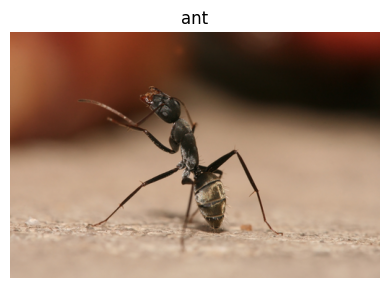


[기본 질문]
This image shows a close-up view of an ant standing on a surface. The ant is positioned in a way that makes it appear to be raising its front legs or antennae, giving it a somewhat dynamic and expressive pose. The background is blurred, which helps to emphasize the ant in the foreground.

[상세 묘사]
The image shows a close-up, detailed view of a black ant standing on a beige or light brown textured surface. The ant is captured from behind and slightly to the side, with its body elevated and its front legs and antennae raised, possibly in a defensive or alert posture.

Colors:
- The ant's body is primarily black with hints of a dark brown shade on the abdomen.
- The surface it's standing on is a muted beige or light brown color, with a slightly rough texture.

Textures:
- The ant's exoskeleton appears smooth and shiny, reflecting some light, which highlights the segmented body and jointed legs.
- The surface beneath the ant looks grainy or sandy, adding a natural, tactile element 

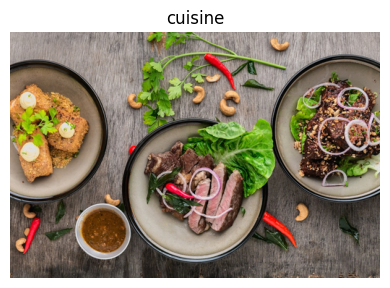


[기본 질문]
The image shows three dishes of food arranged on a wooden surface. The dish on the left contains pieces of fried food garnished with some herbs and white sauce or cream. The dish in the center features slices of cooked meat served with green leafy vegetables and garnished with red and green chili peppers and a ring of sliced red onion. The dish on the right contains what appears to be a salad or a dish with leafy greens, topped with slices of red onion. There is also a small bowl of dipping sauce placed near the bottom left corner. Additionally, there are some cashew nuts, red and green chili peppers, and sprigs of fresh herbs scattered on the wooden surface around the plates for decoration.

[상세 묘사]
The image depicts a neatly arranged food presentation on a rustic wooden surface with a gray, weathered texture. The lighting is natural and soft, highlighting the colors and textures of the dishes without harsh shadows, creating a warm and inviting atmosphere.

There are three ma

In [17]:
for img_name, url in test_images.items():
  b64, img = image_url_to_b64(url)

  print(f"\n{'='*65}")
  print(f"이미지: {img_name}")
  print(f"{'='*65}")

  plt.figure(figsize=(4, 3))
  plt.imshow(img)
  plt.axis("off")
  plt.title(img_name)
  plt.tight_layout()
  plt.show()

  for prompt_name, prompt in prompts.items():
    caption = caption_image(b64, prompt)
    print(f"\n[{prompt_name}]")
    print(caption)



이 단계에서 확인할 점:

- 같은 이미지라도 프롬프트에 따라 출력 길이와 내용이 달라지는가?
- 한국어 요청에 한국어로 응답하는가?

#### Step B3. 텍스트만 vs 이미지+텍스트 비교하기

마지막으로, 이미지 없이 텍스트만 준 경우와 이미지를 함께 준 경우를 비교해 본다.

In [18]:
print("\n" + "=" * 65)
print("[텍스트만 vs 이미지+텍스트 비교]")
print("=" * 65)

b64_ant, _ = image_url_to_b64(list(test_images.values())[0])

text_only = client.chat.completions.create(
  model="gpt-4.1-mini",
  messages=[{"role": "user", "content": "개미에 대해 흥미로운 사실 2가지를 알려줘."}],
  max_tokens=150,
).choices[0].message.content

img_plus = caption_image(b64_ant, "이 이미지의 개미에 대해 관찰할 수 있는 흥미로운 사실 2가지를 알려줘.")

print(f"\n[텍스트만]\n{text_only}")
print(f"\n[이미지+텍스트]\n{img_plus}")


[텍스트만 vs 이미지+텍스트 비교]

[텍스트만]
물론입니다! 개미에 관한 흥미로운 사실 두 가지를 알려드릴게요.

1. **개미는 자신의 몸무게의 수십 배를 들어올릴 수 있어요.**  
   일부 개미 종은 자신의 체중보다 최대 50배 이상 무거운 물체도 들어올릴 수 있는데, 이는 강력한 근육과 작은 체구 덕분에 가능한 일이에요.

2. **개미는 전 세계 어디서나 살지만 남극 대륙에는 없어요.**  
   개미는 거의 모든 환경에 적응해 살고 있지만, 너무 추운 남극에서는 살지 못해 지구 상 대부분의 지역에서 발견됩니다

[이미지+텍스트]
이 개미에 대해 흥미롭게 관찰할 수 있는 두 가지 사실은 다음과 같습니다:

1. **포즈와 행동**: 이 개미는 뒷다리를 들고 앞다리를 위로 뻗으면서 마치 무엇인가를 쳐다보거나 방어하는 듯한 역동적인 포즈를 취하고 있습니다. 이런 자세는 위협을 받았을 때 적을 경고하거나 상대를 위협하기 위한 행동일 수 있습니다.

2. **몸체 구조**: 개미의 몸은 세 부분(머리, 가슴, 배)으로 뚜렷하게 나뉘어 있고, 매우 긴 다리와 마디가 뚜렷한 더듬이를 가지고 있는데, 이는 개미가 주변 환경과 소통하고 탐색하는 데 매우 중요한 역할을 합니다. 특히 이 개미는 가슴이 높게 올라가 있어서 몸이 조금 비틀어진 듯한 독특한 형태를 보여줍니다.

이러한 특징은 개미의 행동 방식과 생존 전략을 이해하는 데 중요한 힌트가 됩니다.




이 단계에서 확인할 점:

- 텍스트만 응답은 일반적 지식 중심인지 확인
- 이미지+텍스트 응답은 실제 이미지 관찰 정보가 추가되는지 확인

### 실습을 마친 뒤 정리

위 실습이 끝나면 아래 내용을 말로 설명할 수 있어야 한다.

1. 시스템 프롬프트는 텍스트 LLM의 응답 형식과 스타일을 바꾼다.
2. Temperature는 창의성과 안정성의 균형에 영향을 준다.
3. 이미지는 base64와 data URL 형태를 거쳐 API에 전달될 수 있다.
4. 같은 이미지라도 프롬프트가 달라지면 캡션 품질과 관점이 달라진다.
5. 이미지 없이 물을 때와 이미지와 함께 물을 때 응답 정보량이 달라진다.

**관찰 과제**

1. 동일한 이미지에 대해 "기본 질문"과 "상세 묘사" 프롬프트의 출력 길이 비교
2. 한국어 요청 시 이미지 내용 설명이 정확한지 확인
3. 텍스트만 요청 vs 이미지+텍스트 요청의 답변 차이 — 이미지가 응답에 어떤 정보를 추가하는지

---

## 핵심 개념 정리

```
텍스트 LLM:
  시스템 프롬프트 → 응답 전략 제어
  Chain-of-Thought → 추론 성능 향상
  Temperature → 창의성 조절

VLM Captioning:
  이미지 → Base64 → data URL → API → ViT 처리 → LLM
  프롬프트 구체성이 캡션 품질을 직접 결정
```

### 혼자 점검하기

아래 질문에 막힘 없이 답하면 이론 이해가 잘 된 것이다.

1. Chat Template에서 `system`, `user`, `assistant` 역할은 각각 무엇인가?
2. 시스템 프롬프트가 출력 형식과 응답 전략에 왜 큰 영향을 주는가?
3. Temperature를 높이면 왜 더 다양한 출력이 나오는가?
4. 이미지를 base64와 data URL로 바꿔 API에 보내는 이유는 무엇인가?
5. Captioning 품질이 프롬프트 구체성에 따라 달라지는 이유는 무엇인가?

---

### Prompt Engineering 핵심 요약  
- Prompt           Engineering              -> Context Engineering -> Harness Engineering
  - Context         - Cot, ToT, SC....         - RAG                  - 통제
  - Instruction                                - Multi Agent          - 3File System
  - Output Indicator                           - Management           - Speckit  
  - input data                                             - Agent들이 Skill사용할 수 있도록 Spec 작성  
                                    Graph Engineering <-  loop Engineering <-|  

* - CoT (Chain of Thought): "단계별로 생각하자"며 하나의 일직선 형태 사고 흐름을 생성한다  
  - CoT-SC (Self-Consistency): 독립적인 CoT 경로 여러 개를 동시에 샘플링한 뒤, 가장 빈도가 높은 최종 답을 선택(앙상블)한다.  
  - ToT (Tree of Thoughts): 중간 단계마다 여러 갈래의 생각(가지)을 만들고, 각 단계를 평가해 유망하지 않은 길은 버리거나(Pruning) 이전으로 되돌아가는(Backtracking) 트리 구조를 쓴다  

트릴리온까지 늘려서 투자하다가 엔트로픽이 안하기로 약속한 재귀적 자기개선(Recursive Self-Improvement) 방법으로 선회 - Mytos 
오픈AI에서도 sol 만들었다가 통제되지 않은 상태로 허깅페이스 공격하는 사건 발생 ㅠㅠ
                                                                             


---
## 다음 교시 예고

**10교시**: VQA(Visual Question Answering) — 이미지와 질문을 함께 입력하여 존재 여부, 속성, 관계 추론, 상식 추론 4단계의 난이도별 질문에 모델이 어떻게 응답하는지 비교한다.

---

## 부록 | 관찰 과제·혼자 점검 모범 답안

이 부록은 교육생이 실습과 이론을 마친 뒤 스스로 이해를 점검할 수 있도록 만든 해설이다.  
정답을 그대로 외우기보다, **응답 결과를 보고 왜 그런 차이가 생겼는지 설명할 수 있는지**를 기준으로 활용하면 된다.

### 관찰 과제 모범 답안

**1. 동일한 이미지에 대해 `기본 질문`과 `상세 묘사` 프롬프트의 출력 길이 비교**

보통 `기본 질문`은 짧고 핵심적인 요약 위주로 응답하고, `상세 묘사`는 색상, 질감, 배경, 조명 같은 세부 요소까지 포함해 더 긴 설명을 생성한다. 이는 모델의 시각 능력 자체가 달라진 것이 아니라, 프롬프트가 요구하는 정보의 범위가 달라졌기 때문이다. 즉, 프롬프트 구체성이 캡션의 길이와 세부 수준을 직접 바꾼다.

**2. 한국어 요청 시 이미지 내용 설명이 정확한지 확인**

한국어 요청을 하면 모델은 같은 시각 정보를 바탕으로 한국어로 설명하려고 한다. 설명의 정확도는 이미지 이해 성능과 언어 생성 성능이 함께 작용한 결과다. 이 관찰을 통해 VLM은 이미지 이해와 언어 생성이 결합된 시스템이며, 언어만 바뀌어도 같은 시각 내용을 다른 형식으로 표현할 수 있다는 점을 확인할 수 있다.

**3. 텍스트만 요청 vs 이미지+텍스트 요청의 답변 차이 — 이미지가 응답에 어떤 정보를 추가하는지**

텍스트만 요청한 경우에는 일반적인 배경지식이나 평균적 설명이 나온다. 반면 이미지+텍스트 요청에서는 실제 사진에 보이는 색, 구조, 배치, 촬영 각도 같은 구체적인 관찰 정보가 답변에 포함된다. 즉, 이미지는 모델이 일반 상식이 아니라 실제 입력 장면을 근거로 답하게 만드는 역할을 한다.

### 혼자 점검하기 모범 답안

**1. Chat Template에서 `system`, `user`, `assistant` 역할은 각각 무엇인가?**

`system`은 모델의 역할, 응답 스타일, 제약 조건을 정하는 상위 지시다. `user`는 실제 질문이나 요청을 담는다. `assistant`는 이전 대화에서 모델이 했던 답변을 기록하는 역할을 한다. 즉, Chat Template는 단순 텍스트가 아니라 역할이 구분된 대화 구조다.

**2. 시스템 프롬프트가 출력 형식과 응답 전략에 왜 큰 영향을 주는가?**

시스템 프롬프트는 모델이 어떤 태도와 형식으로 응답해야 하는지 초기 맥락을 제공한다. 모델은 이 맥락을 기준으로 후속 사용자 요청을 해석하기 때문에, 같은 질문이라도 JSON 형식, 표 형식, 쉬운 설명 같은 차이가 생길 수 있다.

**3. Temperature를 높이면 왜 더 다양한 출력이 나오는가?**

Temperature를 높이면 확률 분포가 더 평탄해져 낮은 확률 후보도 선택될 가능성이 커진다. 그래서 더 다양한 표현이 나오지만, 동시에 더 불안정하거나 덜 일관적인 결과도 증가할 수 있다.

**4. 이미지를 base64와 data URL로 바꿔 API에 보내는 이유는 무엇인가?**

API는 이미지 파일 자체를 바로 보내는 대신, 문자열 기반의 안전한 전송 형식이 필요할 수 있다. base64는 이미지 바이트를 문자열로 바꿔 주고, data URL은 이 문자열이 어떤 형식의 이미지인지 함께 전달할 수 있게 해 준다. 그래서 이미지 데이터를 메시지 안에 포함해 API에 보낼 수 있다.

**5. Captioning 품질이 프롬프트 구체성에 따라 달라지는 이유는 무엇인가?**

모델은 프롬프트가 요구한 정보 범위에 맞춰 응답을 생성한다. `무엇이 보이나요?`는 대략적인 요약을 유도하고, `색상, 질감, 배경까지 설명해 주세요`는 더 세밀한 관찰을 유도한다. 즉, 프롬프트는 모델이 시각 정보 중 어느 부분을 더 적극적으로 언어화할지 결정하는 역할을 한다.

### 활용 팁

이 부록은 아래 순서로 복습할 때 가장 효과적이다.

1. 먼저 실제 응답 결과를 보고 차이를 스스로 설명해 본다.
2. 그다음 모범 답안과 비교한다.
3. 표현이 달라도 핵심 원인을 설명하면 이해한 것으로 본다.
4. 설명이 막히면 시스템 프롬프트와 캡션 프롬프트를 다시 비교한다.